# Housing Prices — Supervised Learning: Regression & Classification

This notebook covers:
1. Load & explore the dataset
2. Handle missing values
3. Select features and target column(s)
4. Train/test split
5. **Linear Regression** — predict `price` (RMSE)
6. **Logistic Regression** — predict `expensive` vs `affordable`, split at the median price (Accuracy)
7. Visualizations & interpretation

> Update the `CSV_PATH` variable in the first code cell if your file lives somewhere else.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_style("whitegrid")
%matplotlib inline

CSV_PATH = "housing_prices_cleaned.csv"  # <-- change this if needed

## 1. Load the Dataset

In [2]:
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
df.head()

Shape: (545, 19)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,mainroad_flag,guestroom_flag,basement_flag,hotwaterheating_flag,airconditioning_flag,prefarea_flag
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,1,0,0,0,1,1
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,1,0,0,0,1,0
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,1,0,1,0,0,1
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,1,0,1,0,1,1
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,1,1,1,0,1,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   price                 545 non-null    int64
 1   area                  545 non-null    int64
 2   bedrooms              545 non-null    int64
 3   bathrooms             545 non-null    int64
 4   stories               545 non-null    int64
 5   mainroad              545 non-null    str  
 6   guestroom             545 non-null    str  
 7   basement              545 non-null    str  
 8   hotwaterheating       545 non-null    str  
 9   airconditioning       545 non-null    str  
 10  parking               545 non-null    int64
 11  prefarea              545 non-null    str  
 12  furnishingstatus      545 non-null    str  
 13  mainroad_flag         545 non-null    int64
 14  guestroom_flag        545 non-null    int64
 15  basement_flag         545 non-null    int64
 16  hotwaterheating_fla

## 2. Handle Missing Values

In [4]:
df.isna().sum()

price                   0
area                    0
bedrooms                0
bathrooms               0
stories                 0
mainroad                0
guestroom               0
basement                0
hotwaterheating         0
airconditioning         0
parking                 0
prefarea                0
furnishingstatus        0
mainroad_flag           0
guestroom_flag          0
basement_flag           0
hotwaterheating_flag    0
airconditioning_flag    0
prefarea_flag           0
dtype: int64

In [5]:
data = df.copy()

# Defensive fill in case a different version of this dataset has gaps
num_cols = data.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if data[col].isna().any():
        data[col] = data[col].fillna(data[col].median())

data.isna().sum()

price                   0
area                    0
bedrooms                0
bathrooms               0
stories                 0
mainroad                0
guestroom               0
basement                0
hotwaterheating         0
airconditioning         0
parking                 0
prefarea                0
furnishingstatus        0
mainroad_flag           0
guestroom_flag          0
basement_flag           0
hotwaterheating_flag    0
airconditioning_flag    0
prefarea_flag           0
dtype: int64

## 3. Select Features & Encode Categoricals

This dataset has both raw yes/no text columns (`mainroad`, `guestroom`, `basement`,
`hotwaterheating`, `airconditioning`, `prefarea`) **and** pre-encoded `_flag` versions
of the same information. We drop the raw text duplicates and keep the flags.
`furnishingstatus` is the one remaining text category, so we label-encode it.

In [6]:
data = data.drop(columns=["mainroad", "guestroom", "basement",
                           "hotwaterheating", "airconditioning", "prefarea"],
                  errors="ignore")

le_furnish = LabelEncoder()
data["furnishingstatus"] = le_furnish.fit_transform(data["furnishingstatus"])

data.head()

,price,area,bedrooms,bathrooms,stories,parking,furnishingstatus,mainroad_flag,guestroom_flag,basement_flag,hotwaterheating_flag,airconditioning_flag,prefarea_flag
0,13300000,7420,4,2,3,2,0,1,0,0,0,1,1
1,12250000,8960,4,4,4,3,0,1,0,0,0,1,0
2,12250000,9960,3,2,2,2,1,1,0,1,0,0,1
3,12215000,7500,4,2,2,3,0,1,0,1,0,1,1
4,11410000,7420,4,1,2,2,0,1,1,1,0,1,0


## 4. Train/Test Split

We'll build two feature sets from the same cleaned data — one for each task below.

## 5. Task A — Linear Regression (Predict `price`)

In [7]:
X_reg = data.drop(columns=["price"])
y_reg = data["price"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Train size:", X_train_r.shape[0], "| Test size:", X_test_r.shape[0])

Train size: 436 | Test size: 109


In [8]:
lin_model = LinearRegression()
lin_model.fit(X_train_r, y_train_r)
y_pred_r = lin_model.predict(X_test_r)

rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
print(f"RMSE (Price prediction): {rmse:,.2f}")
print(f"Average Price in dataset: {y_reg.mean():,.2f}")
print(f"RMSE as % of average price: {rmse / y_reg.mean() * 100:.1f}%")

RMSE (Price prediction): 1,331,071.42
Average Price in dataset: 4,766,729.25
RMSE as % of average price: 27.9%


### Visualize: Actual vs Predicted Price

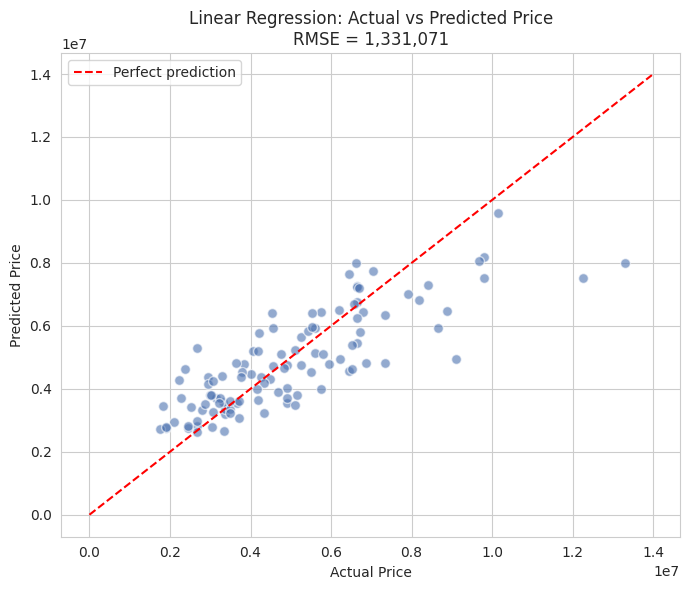

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_r, y_pred_r, alpha=0.6, color="#4C72B0", edgecolor="white", s=50)
lims = [0, max(y_test_r.max(), y_pred_r.max()) * 1.05]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.set_title(f"Linear Regression: Actual vs Predicted Price\nRMSE = {rmse:,.0f}")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Task B — Logistic Regression (Predict `expensive` vs `affordable`)

We create a binary target by splitting `price` at its median: 1 = above-median
("expensive"), 0 = at-or-below median ("affordable").

In [10]:
median_price = data["price"].median()
data["expensive"] = (data["price"] > median_price).astype(int)
print(f"Median price used as split point: {median_price:,.0f}")
data["expensive"].value_counts()

Median price used as split point: 4,340,000


expensive
0    275
1    270
Name: count, dtype: int64

In [11]:
X_clf = data.drop(columns=["price", "expensive"])
y_clf = data["expensive"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Train size:", X_train_c.shape[0], "| Test size:", X_test_c.shape[0])

Train size: 436 | Test size: 109


We scale features before fitting. This puts large-magnitude columns (like
`area`, in the thousands) on the same footing as 0/1 flag columns — it helps the
solver converge faster and makes the resulting coefficients directly comparable.

In [12]:
scaler = StandardScaler()
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_c_scaled, y_train_c)
y_pred_c = log_model.predict(X_test_c_scaled)

acc = accuracy_score(y_test_c, y_pred_c)
print(f"Accuracy (Expensive vs Affordable): {acc:.4f} ({acc*100:.2f}%)")

Accuracy (Expensive vs Affordable): 0.8532 (85.32%)


In [13]:
print("Confusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_c))
print()
print("Classification Report:")
print(classification_report(y_test_c, y_pred_c, target_names=["Affordable", "Expensive"]))

Confusion Matrix:
[[46  9]
 [ 7 47]]

Classification Report:
              precision    recall  f1-score   support

  Affordable       0.87      0.84      0.85        55
   Expensive       0.84      0.87      0.85        54

    accuracy                           0.85       109
   macro avg       0.85      0.85      0.85       109
weighted avg       0.85      0.85      0.85       109



### Visualize: Confusion Matrix

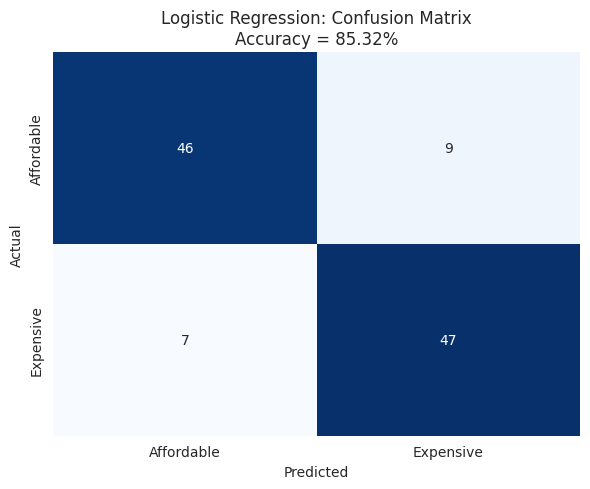

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Affordable", "Expensive"], yticklabels=["Affordable", "Expensive"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Logistic Regression: Confusion Matrix\nAccuracy = {acc*100:.2f}%")
plt.tight_layout()
plt.show()

### Feature Importance (Coefficients)

Positive coefficients raise the odds of being "expensive"; negative coefficients lower them.
Because features were scaled, coefficients are directly comparable to each other.

In [15]:
coef_df = pd.DataFrame({
    "Feature": X_clf.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)
coef_df

,Feature,Coefficient
0,area,0.933363
3,stories,0.850840
10,airconditioning_flag,0.666570
11,prefarea_flag,0.563732
2,bathrooms,0.519689
6,mainroad_flag,0.401590
7,guestroom_flag,0.341207
8,basement_flag,0.340892
5,furnishingstatus,-0.306119
1,bedrooms,0.204589


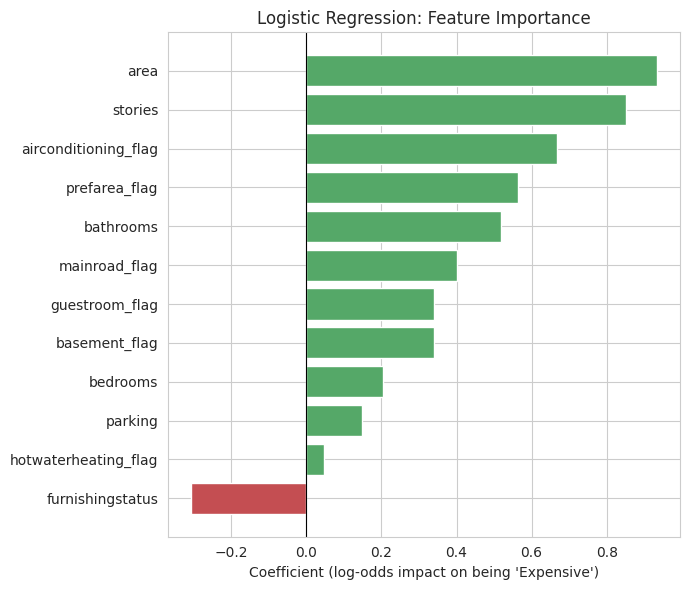

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
coef_sorted = coef_df.sort_values("Coefficient")
colors = ["#C44E52" if c < 0 else "#55A868" for c in coef_sorted["Coefficient"]]
ax.barh(coef_sorted["Feature"], coef_sorted["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (log-odds impact on being 'Expensive')")
ax.set_title("Logistic Regression: Feature Importance")
plt.tight_layout()
plt.show()

### Bonus: Price vs Area, colored by Air Conditioning

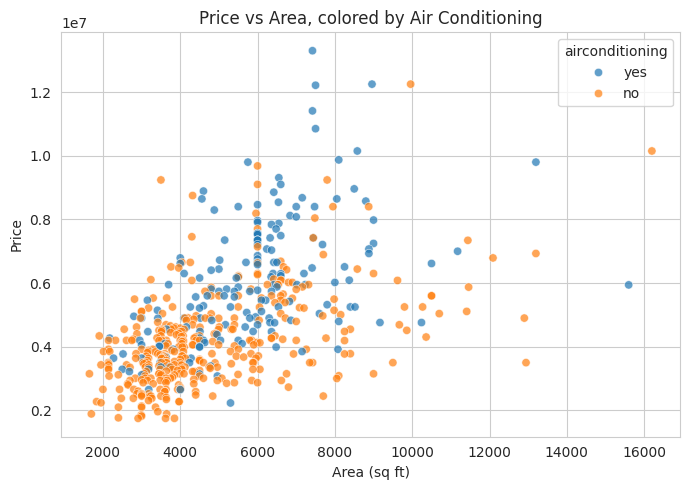

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="area", y="price", hue="airconditioning", ax=ax, alpha=0.7)
ax.set_xlabel("Area (sq ft)")
ax.set_ylabel("Price")
ax.set_title("Price vs Area, colored by Air Conditioning")
plt.tight_layout()
plt.show()

## 7. Summary

| Model Type | Target | Evaluation Metric |
|---|---|---|
| Linear Regression | price (continuous) | RMSE |
| Logistic Regression | expensive (median split) | Accuracy Score |

In [18]:
summary = pd.DataFrame({
    "Model Type": ["Linear Regression", "Logistic Regression"],
    "Target": ["price (continuous)", "expensive (median split)"],
    "Evaluation Metric": ["RMSE", "Accuracy Score"],
    "Result": [f"{rmse:,.2f}", f"{acc:.4f}"]
})
summary

,Model Type,Target,Evaluation Metric,Result
0,Linear Regression,price (continuous),RMSE,"1,331,071.42"
1,Logistic Regression,expensive (median split),Accuracy Score,0.8532


### Interpretation

- **Linear Regression (price):** RMSE of roughly 1.33M against an average price of
  ~4.77M means typical prediction error is about 28% of the average house price.
  That's a moderate fit — reasonable for a small feature set with no engineered
  interactions (e.g. price-per-sqft, neighborhood effects), but there's clear room
  to improve with more features or a non-linear model.
- **Logistic Regression (expensive vs affordable):** ~85% accuracy is a strong
  result — notably higher than the survival-prediction task on a different dataset,
  which suggests the available features (area, stories, air conditioning, preferred
  area, bathrooms) separate expensive from affordable homes fairly cleanly.
- **Key predictors:** `area` and `stories` carry the most weight, followed closely
  by `airconditioning`, `prefarea`, and `bathrooms` — all intuitive: bigger, taller,
  better-located, better-equipped homes tend to cost more.